# Supplementary Figure — Detailed Annotation Comparison

**Six-panel supplementary figure** providing the method-level detail that the
main concordance ladder figure intentionally omits.

| Panel | Content | Purpose |
|-------|---------|---------|
| **A** | Reciprocal gene-body coverage scatter (RBH pairs) | Shows the joint distribution that rung 2 of the ladder thresholds on |
| **B** | Gene presence/absence breakdown per assembly | Shows *which* loci disagree and whether the disagreement is systematic |
| **C** | Transcript structural match type distribution | Decomposes rung 3 into exact / intron-match / partial / unmatched |
| **D** | CDS classification breakdown | Decomposes rung 4 into Full_Match / truncation / extension / frameshift |
| **E** | Per-assembly concordance across all rungs (multi-rung dot strip) | Full version of the right panel in the main figure, all rungs overlaid |
| **F** | Multi-mapping type comparison (Ensembl vs CAT) | Method-specific breakdown excluded from main figure |

### Data requirements
Reads pre-computed summary TSVs from the main QC report notebook,
plus the funnel per-assembly table from the primary figure notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 7.5,
    'ytick.labelsize': 7.5,
    'legend.fontsize': 7,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

print(f'pandas {pd.__version__}, numpy {np.__version__}')

pandas 3.0.1, numpy 2.4.2


## Configuration

In [2]:
OUTPUT_DIR  = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results')
SUMMARY_DIR = OUTPUT_DIR / 'summary_stats'
FIGURE_DIR  = OUTPUT_DIR / 'figures'
FIGURE_DIR.mkdir(exist_ok=True, parents=True)

# Colour palette
GENE_COL = '#2a9d8f'
TX_COL   = '#457b9d'
CDS_COL  = '#e76f51'
ENS_COL  = '#1a6faf'
CAT_COL  = '#d4873b'
BOTH_COL = '#2a9d8f'

print(f'Summary dir: {SUMMARY_DIR}')
print(f'Figure dir:  {FIGURE_DIR}')

Summary dir: /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/summary_stats
Figure dir:  /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/figures


## Load data

In [3]:
def _load(name, required=True):
    """Load a summary TSV, returning None if not found and not required."""
    path = SUMMARY_DIR / name
    if path.exists():
        return pd.read_csv(path, sep='\t')
    if required:
        raise FileNotFoundError(f'Required file not found: {path}')
    print(f'  (optional) not found: {name}')
    return None

# Core summaries
presence_summary = _load('gene_presence_summary.tsv')
rbh_cls          = _load('rbh_classifications.tsv')
coding_cls       = _load('coding_classifications.tsv')
coverage_sample  = _load('rbh_coverage_sample.tsv')
per_asm_tx       = _load('transcript_concordance_per_assembly.tsv')
mm_cls           = _load('multi_mapping_classifications.tsv', required=False)

# Funnel per-assembly table from primary figure notebook
funnel           = _load('funnel_per_assembly_all_rungs.tsv', required=False)

print('\nAll data loaded.')


All data loaded.


---
## Build figure

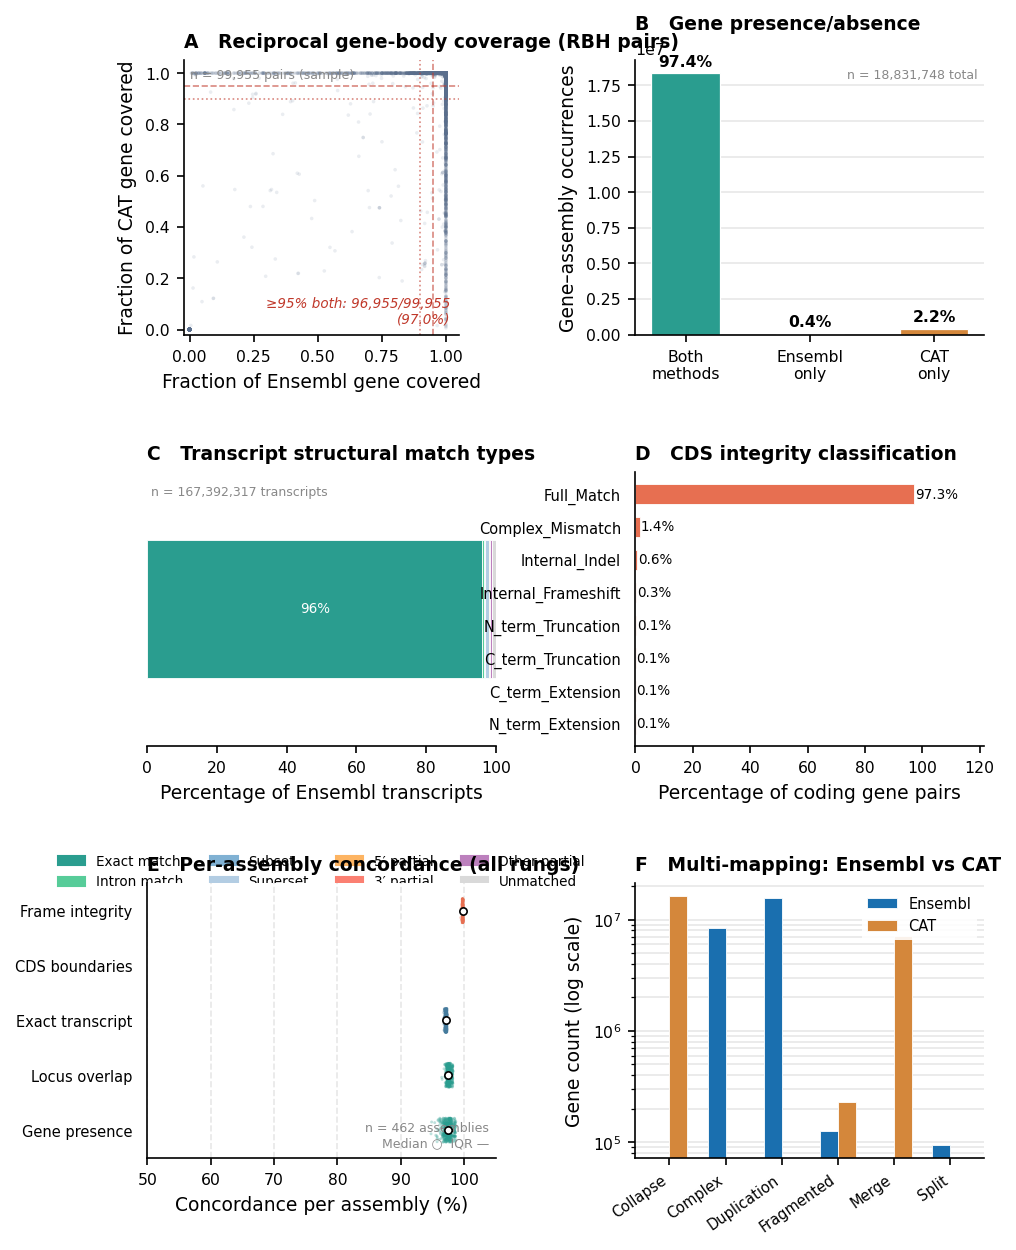

✓ Saved supplementary_annotation_comparison.{png,pdf}


In [4]:
fig = plt.figure(figsize=(7.2, 9.5))  # Nature double-column, tall
gs  = GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.40)


# ═══════════════════════════════════════════════════════════════════════════
# A — Reciprocal gene-body coverage scatter
# ═══════════════════════════════════════════════════════════════════════════
ax_a = fig.add_subplot(gs[0, 0])

ax_a.scatter(
    coverage_sample['frac_ensembl_covered'],
    coverage_sample['frac_cat_covered'],
    alpha=0.12, s=3, color='#5a6e8c', edgecolors='none', rasterized=True,
)

# Threshold lines (matching rung 2 = 95%)
for threshold, ls, lbl in [(0.95, '--', '95%'), (0.90, ':', '90%')]:
    ax_a.axhline(threshold, color='#c0392b', linestyle=ls, alpha=0.6, lw=0.8)
    ax_a.axvline(threshold, color='#c0392b', linestyle=ls, alpha=0.6, lw=0.8)

# Annotate quadrant counts
n_total = len(coverage_sample)
n_high  = ((coverage_sample['frac_ensembl_covered'] >= 0.95) &
           (coverage_sample['frac_cat_covered'] >= 0.95)).sum()
ax_a.text(
    0.97, 0.03,
    f'\u226595% both: {n_high:,}/{n_total:,}\n({n_high/n_total:.1%})',
    transform=ax_a.transAxes, fontsize=6.5, ha='right', va='bottom',
    color='#c0392b', fontstyle='italic',
)

ax_a.set_xlabel('Fraction of Ensembl gene covered')
ax_a.set_ylabel('Fraction of CAT gene covered')
ax_a.set_xlim(-0.02, 1.05)
ax_a.set_ylim(-0.02, 1.05)
ax_a.set_aspect('equal', adjustable='box')
ax_a.set_title('A   Reciprocal gene-body coverage (RBH pairs)',
               fontsize=9, fontweight='bold', loc='left')
ax_a.spines[['top', 'right']].set_visible(False)
ax_a.text(0.02, 0.97, f'n = {n_total:,} pairs (sample)',
          transform=ax_a.transAxes, fontsize=6, va='top', color='#888')


# ═══════════════════════════════════════════════════════════════════════════
# B — Gene presence/absence breakdown
# ═══════════════════════════════════════════════════════════════════════════
ax_b = fig.add_subplot(gs[0, 1])

pres = presence_summary.iloc[0]
cats   = ['Both\nmethods', 'Ensembl\nonly', 'CAT\nonly']
counts = [pres['both'], pres['ensembl_only'], pres['cat_only']]
colors = [BOTH_COL, ENS_COL, CAT_COL]

bars = ax_b.bar(cats, counts, color=colors, edgecolor='white',
                linewidth=0.6, width=0.55)

for bar, cnt in zip(bars, counts):
    pct = cnt / pres['total'] * 100
    ax_b.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(counts) * 0.015,
        f'{pct:.1f}%', ha='center', va='bottom',
        fontsize=7.5, fontweight='bold',
    )

ax_b.set_ylabel('Gene\u2013assembly occurrences')
ax_b.set_title('B   Gene presence/absence', fontsize=9,
               fontweight='bold', loc='left')
ax_b.spines[['top', 'right']].set_visible(False)
ax_b.set_axisbelow(True)
ax_b.yaxis.grid(True, alpha=0.3)
ax_b.text(0.98, 0.97,
          f'n = {int(pres["total"]):,} total',
          transform=ax_b.transAxes, fontsize=6, ha='right', va='top', color='#888')


# ═══════════════════════════════════════════════════════════════════════════
# C — Transcript structural match types (stacked horizontal bar)
# ═══════════════════════════════════════════════════════════════════════════
ax_c = fig.add_subplot(gs[1, 0])

tx_cols_map = {
    'n_ens_exact':         ('Exact match',   '#2a9d8f'),
    'n_ens_intron_match':  ('Intron match',   '#57cc99'),
    'n_ens_subset':        ('Subset',         '#80b1d3'),
    'n_ens_superset':      ('Superset',       '#b3cde3'),
    'n_ens_partial_5':     ("5\u2032 partial", '#fdb462'),
    'n_ens_partial_3':     ("3\u2032 partial", '#fb8072'),
    'n_ens_other_partial': ('Other partial',   '#bc80bd'),
    'n_ens_unmatched':     ('Unmatched',       '#d9d9d9'),
}
available = {k: v for k, v in tx_cols_map.items() if k in per_asm_tx.columns}
totals    = {k: per_asm_tx[k].sum() for k in available}
grand_tot = sum(totals.values())

left = 0
for col_name, (label, colour) in available.items():
    width = totals[col_name] / grand_tot * 100
    ax_c.barh(0, width, left=left, color=colour, edgecolor='white',
              linewidth=0.4, height=0.45)
    if width > 4:
        ax_c.text(left + width / 2, 0, f'{width:.0f}%',
                  va='center', ha='center', fontsize=6.5,
                  color='white' if width > 8 else '#333')
    left += width

ax_c.set_xlim(0, 100)
ax_c.set_ylim(-0.45, 0.45)
ax_c.set_yticks([])
ax_c.set_xlabel('Percentage of Ensembl transcripts')
ax_c.set_title('C   Transcript structural match types',
               fontsize=9, fontweight='bold', loc='left')
ax_c.spines[['top', 'right', 'left']].set_visible(False)
ax_c.tick_params(left=False)

legend_patches = [mpatches.Patch(color=v[1], label=v[0])
                  for v in available.values()]
ax_c.legend(
    handles=legend_patches, loc='upper center',
    bbox_to_anchor=(0.5, -0.35), ncol=4, fontsize=6.5,
    framealpha=0.9, edgecolor='none',
)
ax_c.text(0.01, 0.95, f'n = {grand_tot:,} transcripts',
          transform=ax_c.transAxes, fontsize=6, va='top', color='#888')


# ═══════════════════════════════════════════════════════════════════════════
# D — CDS classification breakdown
# ═══════════════════════════════════════════════════════════════════════════
ax_d = fig.add_subplot(gs[1, 1])

cls_sorted = coding_cls.sort_values('count', ascending=True).copy()
y_d = range(len(cls_sorted))

ax_d.barh(
    list(y_d), cls_sorted['percentage'].values * 100,
    color=CDS_COL, edgecolor='white', linewidth=0.4, height=0.6,
)
ax_d.set_yticks(list(y_d))
ax_d.set_yticklabels(cls_sorted['classification'].values, fontsize=7)
ax_d.set_xlabel('Percentage of coding gene pairs')
ax_d.set_title('D   CDS integrity classification',
               fontsize=9, fontweight='bold', loc='left')
ax_d.spines[['top', 'right']].set_visible(False)
ax_d.tick_params(left=False)
ax_d.set_axisbelow(True)
ax_d.set_xlim(0, cls_sorted['percentage'].max() * 100 * 1.25)

for i, (_, row) in enumerate(cls_sorted.iterrows()):
    pct = row['percentage'] * 100
    ax_d.text(pct + 0.3, i, f'{pct:.1f}%', va='center', fontsize=6.5)


# ═══════════════════════════════════════════════════════════════════════════
# E — Per-assembly concordance across all funnel rungs
# ═══════════════════════════════════════════════════════════════════════════
ax_e = fig.add_subplot(gs[2, 0])

if funnel is not None and not funnel.empty:
    rung_defs = [
        ('Gene presence',    'pct_gene_presence',    GENE_COL),
        ('Locus overlap',    'pct_high_overlap',     GENE_COL),
        ('Exact transcript', 'pct_exact_transcript', TX_COL),
        ('CDS boundaries',   'pct_cds_concordance',  CDS_COL),
        ('Frame integrity',  'pct_frame_integrity',  CDS_COL),
    ]

    rng = np.random.default_rng(99)
    for i, (lbl, col, colour) in enumerate(rung_defs):
        vals = funnel[col].dropna() * 100
        jitter = rng.uniform(-0.22, 0.22, size=len(vals))
        ax_e.scatter(
            vals, i + jitter,
            s=2, alpha=0.3, color=colour, edgecolors='none', rasterized=True,
        )
        med = vals.median()
        q25, q75 = vals.quantile(0.25), vals.quantile(0.75)
        ax_e.plot([q25, q75], [i, i], color='black', lw=1.5, zorder=3)
        ax_e.plot(med, i, 'o', color='white', markersize=3.5,
                  markeredgecolor='black', markeredgewidth=0.8, zorder=4)

    ax_e.set_yticks(range(len(rung_defs)))
    ax_e.set_yticklabels([r[0] for r in rung_defs], fontsize=7)
    ax_e.set_xlabel('Concordance per assembly (%)')
    ax_e.set_xlim(50, 105)
    ax_e.set_ylim(-0.5, len(rung_defs) - 0.5)
    ax_e.xaxis.grid(True, alpha=0.3, linestyle='--')
    ax_e.set_axisbelow(True)
    ax_e.text(
        0.98, 0.03,
        f'n = {len(funnel):,} assemblies\nMedian \u25cb  IQR \u2014',
        transform=ax_e.transAxes, fontsize=6, ha='right', va='bottom',
        color='#888',
    )
else:
    # Fallback: single-rung histogram from transcript concordance
    per_asm_vals = per_asm_tx['transcript_concordance_rate'] * 100
    ax_e.hist(per_asm_vals, bins=40, color=TX_COL, edgecolor='white', lw=0.4)
    ax_e.axvline(per_asm_vals.median(), color='black', ls='--', lw=1)
    ax_e.set_xlabel('Mean transcript concordance (%) per assembly')
    ax_e.set_ylabel('Number of assemblies')

ax_e.set_title('E   Per-assembly concordance (all rungs)',
               fontsize=9, fontweight='bold', loc='left')
ax_e.spines[['top', 'right']].set_visible(False)
ax_e.tick_params(left=False)


# ═══════════════════════════════════════════════════════════════════════════
# F — Multi-mapping classification: Ensembl vs CAT
# ═══════════════════════════════════════════════════════════════════════════
ax_f = fig.add_subplot(gs[2, 1])

if mm_cls is not None and len(mm_cls) > 0:
    mm_pivot = mm_cls.pivot_table(
        index='classification', columns='source',
        values='count', fill_value=0,
    )
    x = np.arange(len(mm_pivot.index))
    w = 0.32

    if 'ensembl' in mm_pivot.columns:
        ax_f.bar(x - w / 2, mm_pivot['ensembl'], w,
                 label='Ensembl', color=ENS_COL, edgecolor='white', lw=0.4)
    if 'cat' in mm_pivot.columns:
        ax_f.bar(x + w / 2, mm_pivot['cat'], w,
                 label='CAT', color=CAT_COL, edgecolor='white', lw=0.4)

    ax_f.set_xticks(x)
    ax_f.set_xticklabels(mm_pivot.index, rotation=35, ha='right', fontsize=7)
    ax_f.set_ylabel('Gene count (log scale)')
    ax_f.set_yscale('log')
    ax_f.legend(fontsize=7, framealpha=0.9, edgecolor='none')
    ax_f.yaxis.grid(True, alpha=0.3, which='both')
    ax_f.set_axisbelow(True)
else:
    ax_f.text(0.5, 0.5, 'Multi-mapping data not available',
              ha='center', va='center', transform=ax_f.transAxes, color='#888')

ax_f.set_title('F   Multi-mapping: Ensembl vs CAT',
               fontsize=9, fontweight='bold', loc='left')
ax_f.spines[['top', 'right']].set_visible(False)


# ═══════════════════════════════════════════════════════════════════════════
# Save
# ═══════════════════════════════════════════════════════════════════════════
for ext in ['png', 'pdf']:
    fig.savefig(
        FIGURE_DIR / f'supplementary_annotation_comparison.{ext}',
        dpi=300, bbox_inches='tight',
    )

plt.show()
print('\u2713 Saved supplementary_annotation_comparison.{png,pdf}')

---
## Caption draft

In [5]:
# Pull key numbers for caption
pres = presence_summary.iloc[0]
_n_both  = int(pres['both'])
_n_total = int(pres['total'])
_pct_both = _n_both / _n_total * 100

_n_sample = len(coverage_sample)
_n_high_cov = int(((coverage_sample['frac_ensembl_covered'] >= 0.95) &
                   (coverage_sample['frac_cat_covered'] >= 0.95)).sum())
_pct_high_cov = _n_high_cov / _n_sample * 100

# Top CDS classification
_top_cds = coding_cls.sort_values('count', ascending=False).iloc[0]

caption = f"""\
**Supplementary Figure X. Detailed Ensembl\u2013CAT annotation comparison.**

**(A)** Reciprocal gene-body coverage for {_n_sample:,} sampled RBH pairs.
Dashed red lines mark the 95% threshold used for the main figure ladder
(rung 2); {_pct_high_cov:.1f}% of pairs exceed this threshold in both
directions.

**(B)** Gene presence/absence across all assemblies. {_pct_both:.1f}% of
gene\u2013assembly occurrences ({_n_both:,} / {_n_total:,}) are detected by
both methods. Gene identity is by HGNC name; bare Ensembl stable IDs
(ENSG\u2026 without a display name) are excluded.

**(C)** Transcript structural match type distribution for Ensembl
transcripts matched against CAT. Exact match = identical exon coordinates;
intron match = identical intron chain with different UTR boundaries;
remaining categories represent progressively more divergent structures.

**(D)** CDS integrity classification for protein-coding RBH gene pairs
with CDS in both annotations. Most common classification:
{_top_cds['classification']} ({_top_cds['percentage']*100:.1f}%).
Start/stop codon matching uses a 3 bp tolerance.

**(E)** Per-assembly distributions for all five concordance ladder rungs
(cf. main Figure X). Open circle = median; black bar = interquartile range;
individual dots = one assembly each.

**(F)** Multi-mapping classification comparing Ensembl and CAT.
Categories reflect one-to-many or many-to-one projection patterns
(Split, Merge, Duplication, Collapse, Fragmented).
"""

print(caption)

**Supplementary Figure X. Detailed Ensembl–CAT annotation comparison.**

**(A)** Reciprocal gene-body coverage for 99,955 sampled RBH pairs.
Dashed red lines mark the 95% threshold used for the main figure ladder
(rung 2); 97.0% of pairs exceed this threshold in both
directions.

**(B)** Gene presence/absence across all assemblies. 97.4% of
gene–assembly occurrences (18,347,401 / 18,831,748) are detected by
both methods. Gene identity is by HGNC name; bare Ensembl stable IDs
(ENSG… without a display name) are excluded.

**(C)** Transcript structural match type distribution for Ensembl
transcripts matched against CAT. Exact match = identical exon coordinates;
intron match = identical intron chain with different UTR boundaries;
remaining categories represent progressively more divergent structures.

**(D)** CDS integrity classification for protein-coding RBH gene pairs
with CDS in both annotations. Most common classification:
Full_Match (97.3%).
Start/stop codon matching uses a 3 bp tole

---
## Notes

- Panel **A** uses a random sample of RBH pairs (default 10,000) for
  rendering speed. The threshold statistics are computed on the full
  dataset in the main notebook.
- Panel **E** requires the `funnel_per_assembly_all_rungs.tsv` file
  produced by running the primary figure notebook first. If this file
  is not available, the panel falls back to a single-rung histogram
  of transcript concordance.
- The stacked bar in panel **C** shows the Ensembl\u2192CAT direction
  only. The reverse direction (CAT\u2192Ensembl) shows similar patterns
  and is available in the per-assembly concordance files.
- Panel **F** may be empty if the multi-mapping analysis was not run.
  This is expected for test datasets.